#### 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

pd.set_option('display.max_columns', None)

#### 2. Load Dataset

In [2]:
df = pd.read_csv('car_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (4340, 9)


,name,year,selling_price,present_price,kms_driven,fuel_type,seller_type,transmission,owner
0,Tata Nexon,2020,8.67,10.31,16814,Petrol,Individual,Manual,0
1,Mahindra XUV500,2020,20.32,23.81,15009,Petrol,Individual,Manual,0
2,Maruti Alto,2020,2.92,3.18,20869,Petrol,Dealer,Manual,0
3,Mahindra Bolero,2020,7.54,10.29,13745,Petrol,Individual,Manual,0
4,Hyundai i20,2020,7.80,8.21,10089,Diesel,Dealer,Manual,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           4340 non-null   object 
 1   year           4340 non-null   int64  
 2   selling_price  4340 non-null   float64
 3   present_price  4340 non-null   float64
 4   kms_driven     4340 non-null   int64  
 5   fuel_type      4340 non-null   object 
 6   seller_type    4340 non-null   object 
 7   transmission   4340 non-null   object 
 8   owner          4340 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 305.3+ KB


In [5]:
df.describe()

,year,selling_price,present_price,kms_driven,owner
count,4340.000000,4340.000000,4340.000000,4340.000000,4340.000000
mean,2013.065899,8.294509,16.841304,61972.912903,0.381567
std,4.959275,10.083539,16.989411,35481.990160,0.702959
min,2003.000000,0.420000,2.650000,5184.000000,0.000000
25%,2009.000000,2.667500,7.170000,33029.250000,0.000000
50%,2014.000000,4.740000,10.170000,55808.500000,0.000000
75%,2017.000000,9.080000,19.215000,85046.750000,1.000000
max,2020.000000,57.000000,60.000000,178599.000000,3.000000


#### 3. Data Cleaning

In [6]:
# Check missing values
print("Missing values per column:\n")
print(df.isnull().sum())

Missing values per column:

name             0
year             0
selling_price    0
present_price    0
kms_driven       0
fuel_type        0
seller_type      0
transmission     0
owner            0
dtype: int64


In [8]:
# Check duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [9]:
# Unique values for categorical columns
cat_cols = ['fuel_type', 'seller_type', 'transmission', 'owner']
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

fuel_type: ['Petrol' 'Diesel' 'CNG']
seller_type: ['Individual' 'Dealer']
transmission: ['Manual' 'Automatic']
owner: [0 2 1 3]


In [10]:
# How many unique car models/names are there?
print(f"Unique car names: {df['name'].nunique()}")
df['name'].value_counts().head(10)

Unique car names: 34


name
BMW 3 Series        149
Toyota Etios        146
Renault Duster      144
Mahindra XUV500     144
Volkswagen Polo     141
Mahindra Scorpio    141
Hyundai i20         140
Renault Kwid        135
Ford Figo           135
Mahindra Bolero     134
Name: count, dtype: int64

#### 4. EDA

###### 4.1 Target Variable Distributions

In [12]:
import os

os.makedirs("plots", exist_ok=True)

plt.tight_layout()
plt.savefig("plots/price_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

<Figure size 1000x600 with 0 Axes>

In [13]:
plt.tight_layout()
plt.savefig("price_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

<Figure size 1000x600 with 0 Axes>

In [14]:
import os
print(os.getcwd())

c:\Users\ayush\Desktop\Used Car Price


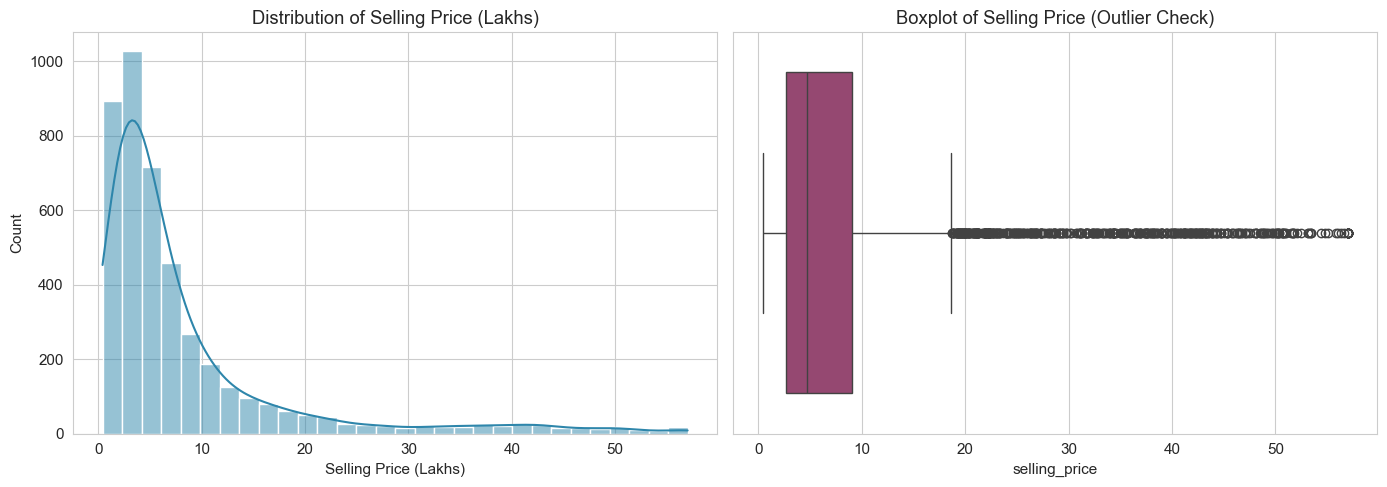

Skewness: 2.628
Kurtosis: 7.113


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['selling_price'], kde=True, bins=30, color='#2E86AB', ax=axes[0])
axes[0].set_title('Distribution of Selling Price (Lakhs)')
axes[0].set_xlabel('Selling Price (Lakhs)')

sns.boxplot(x=df['selling_price'], color='#A23B72', ax=axes[1])
axes[1].set_title('Boxplot of Selling Price (Outlier Check)')

plt.tight_layout()
plt.savefig('plots/price_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Skewness: {df['selling_price'].skew():.3f}")
print(f"Kurtosis: {df['selling_price'].kurt():.3f}")

###### 4.2 Numerical Feature Distributions

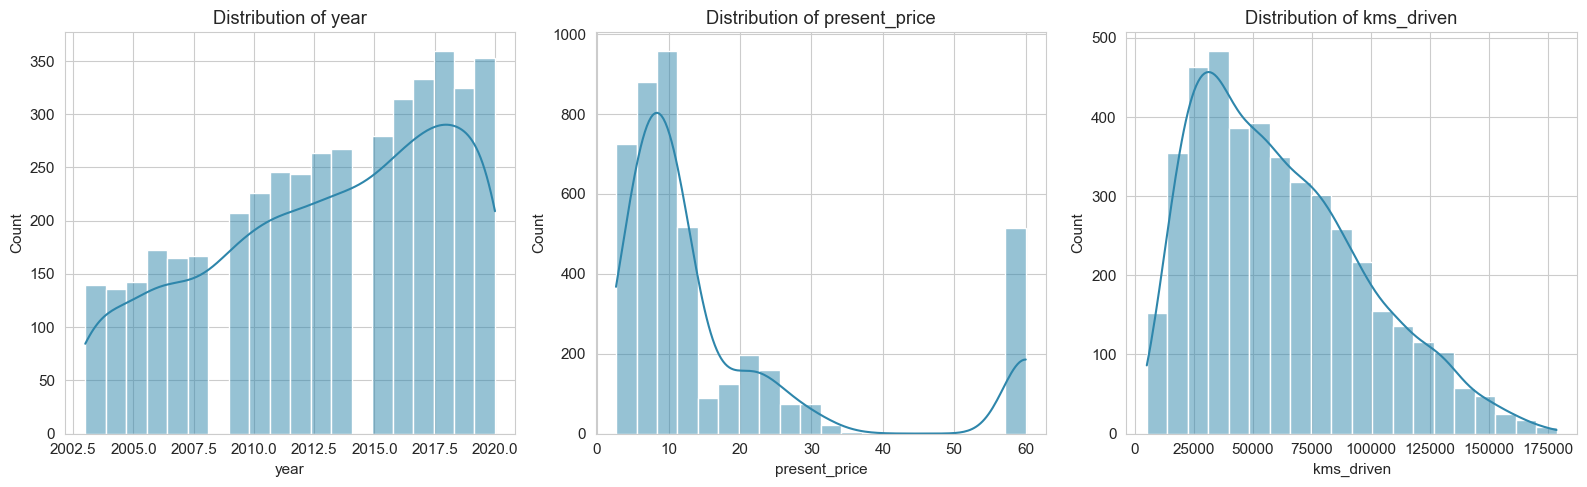

In [16]:
num_cols = ['year', 'present_price', 'kms_driven']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, bins=20, color='#2E86AB', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('plots/numerical_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

###### 4.3 Categorical Feature Counts

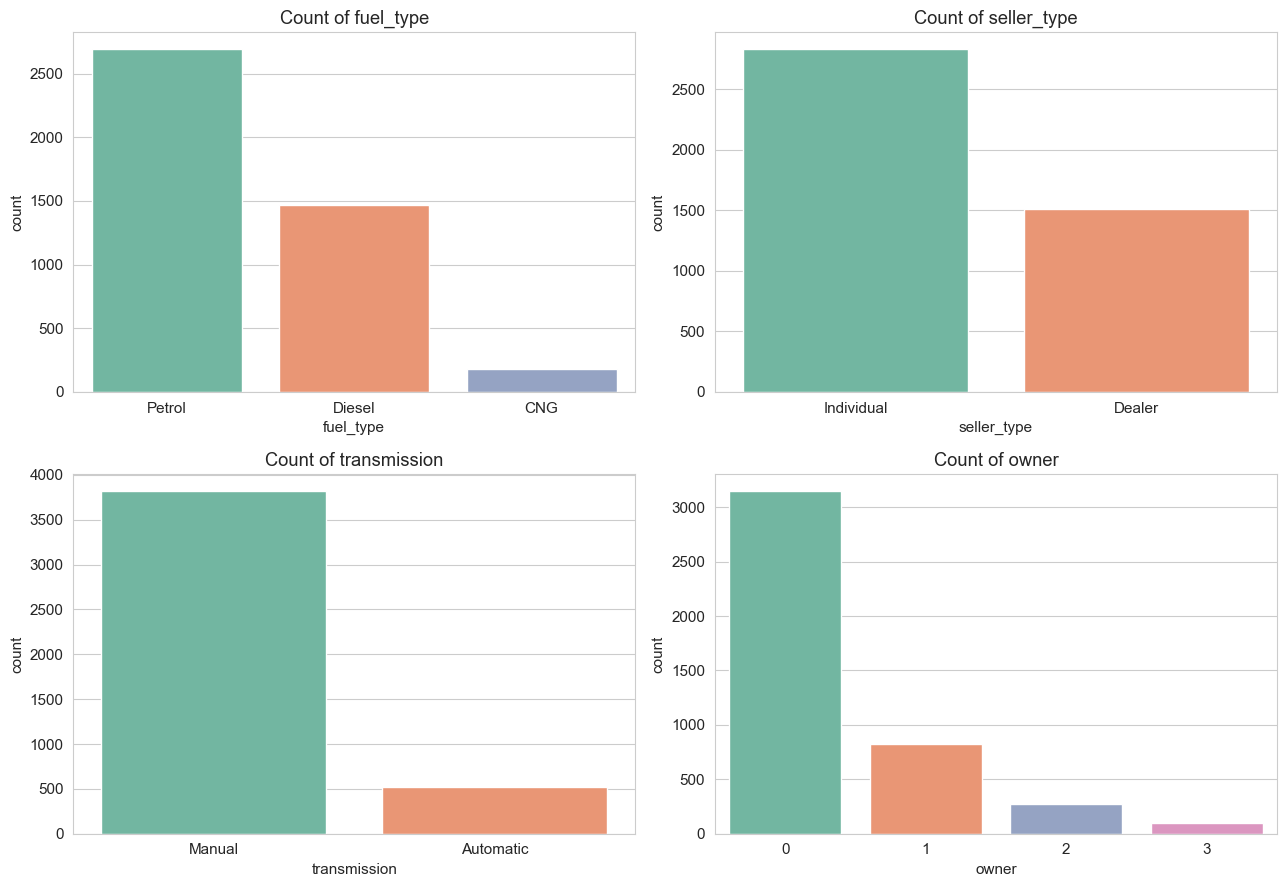

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(x=df[col], order=order, palette='Set2', ax=axes[i])
    axes[i].set_title(f'Count of {col}')
plt.tight_layout()
plt.savefig('plots/categorical_counts.png', dpi=120, bbox_inches='tight')
plt.show()

###### 4.4 Selling Price vs Categorical Features

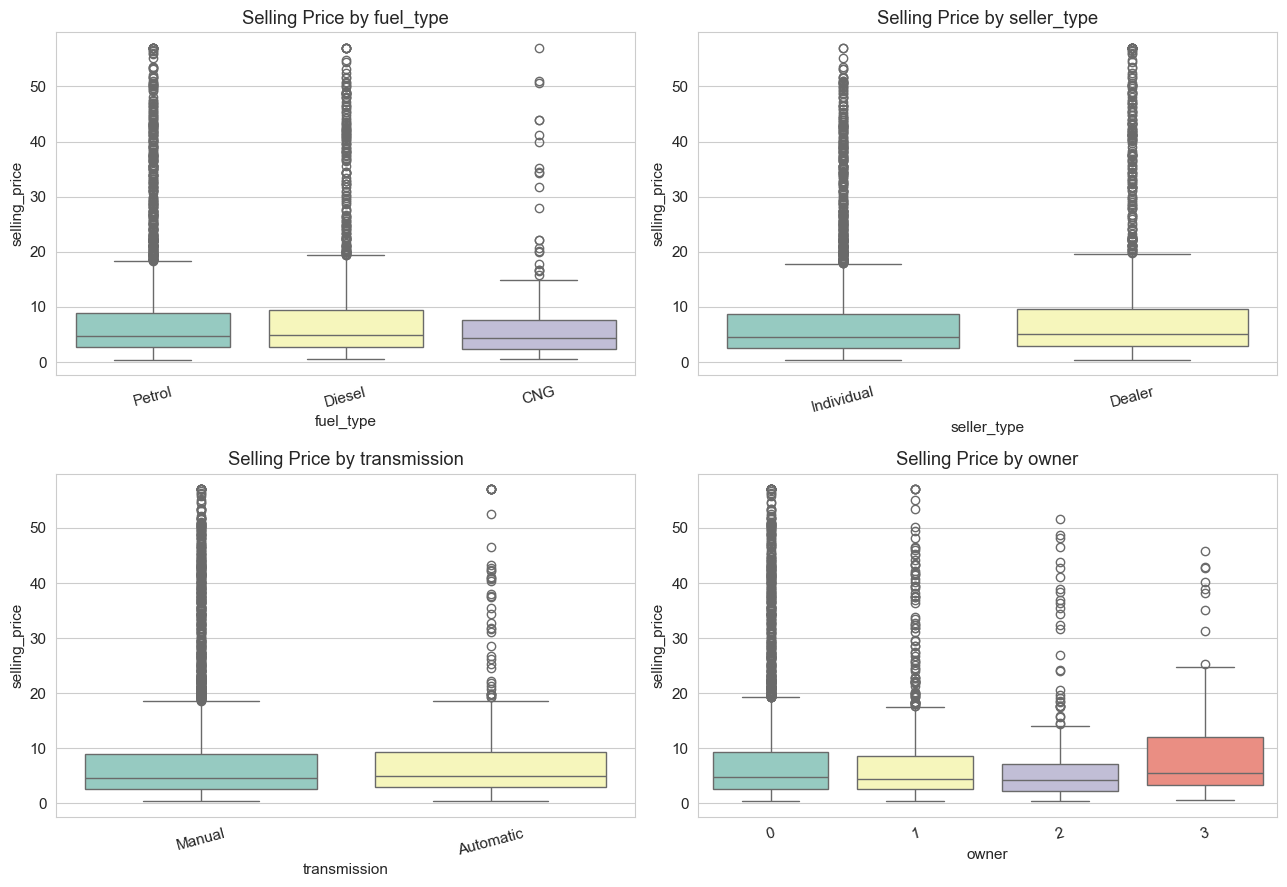

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.boxplot(x=df[col], y=df['selling_price'], palette='Set3', ax=axes[i])
    axes[i].set_title(f'Selling Price by {col}')
    axes[i].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('plots/price_by_categorical.png', dpi=120, bbox_inches='tight')
plt.show()

###### 4.5 Correlation Heatmap

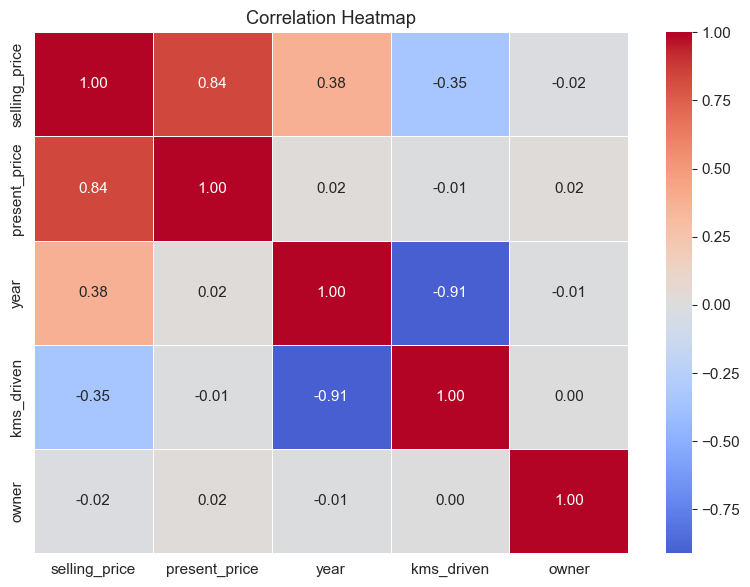

In [19]:
plt.figure(figsize=(8, 6))
corr_cols = ['selling_price', 'present_price', 'year', 'kms_driven', 'owner']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

###### 4.6 Present Price vs Selling Price

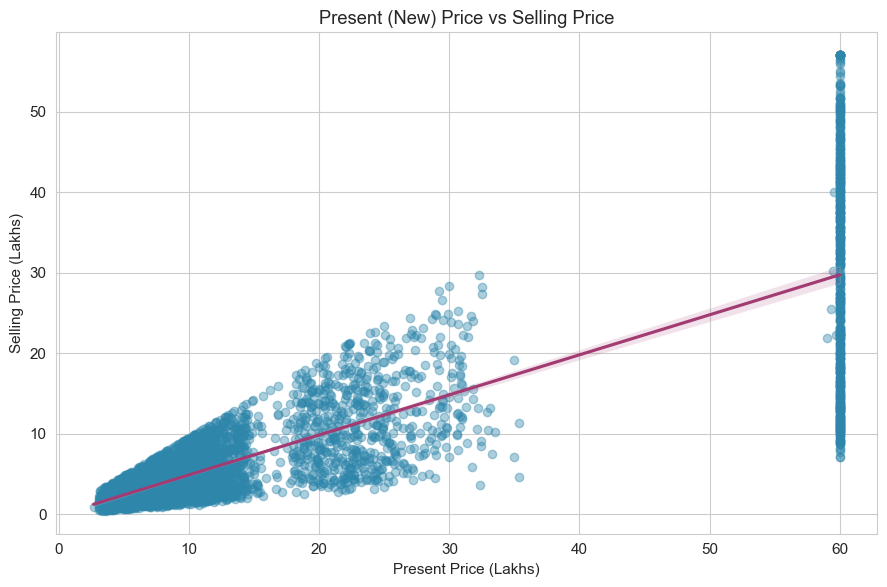

In [20]:
plt.figure(figsize=(9, 6))
sns.regplot(x='present_price', y='selling_price', data=df,
            scatter_kws={'alpha': 0.4, 'color': '#2E86AB'}, line_kws={'color': '#A23B72'})
plt.title('Present (New) Price vs Selling Price')
plt.xlabel('Present Price (Lakhs)')
plt.ylabel('Selling Price (Lakhs)')
plt.tight_layout()
plt.savefig('plots/present_vs_selling_price.png', dpi=120, bbox_inches='tight')
plt.show()

###### 4.7 Depreciation: Car Age vs Selling Price

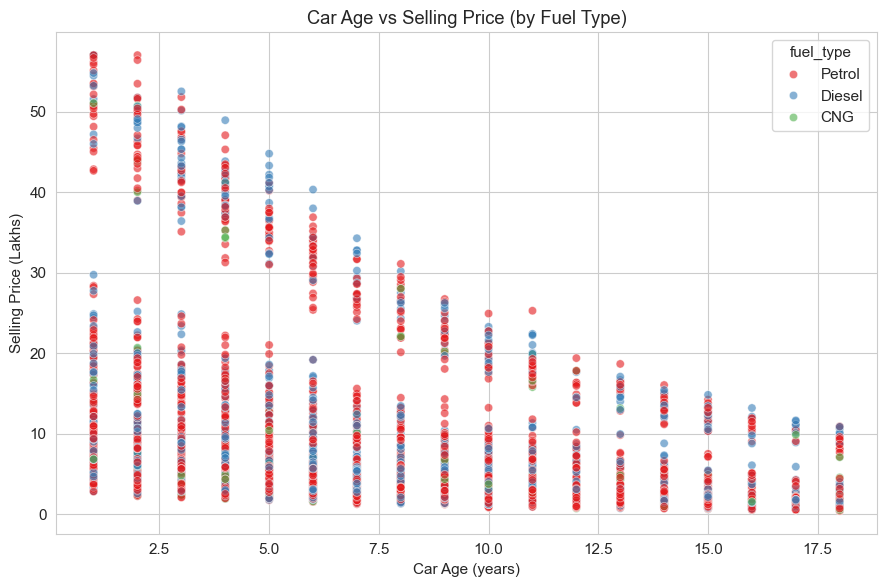

In [21]:
df['car_age_eda'] = 2021 - df['year']

plt.figure(figsize=(9, 6))
sns.scatterplot(x='car_age_eda', y='selling_price', hue='fuel_type', data=df, alpha=0.6, palette='Set1')
plt.title('Car Age vs Selling Price (by Fuel Type)')
plt.xlabel('Car Age (years)')
plt.ylabel('Selling Price (Lakhs)')
plt.tight_layout()
plt.savefig('plots/age_vs_price.png', dpi=120, bbox_inches='tight')
plt.show()

df.drop(columns=['car_age_eda'], inplace=True)

###### 4.8 Pairplot of Key Numerical Features

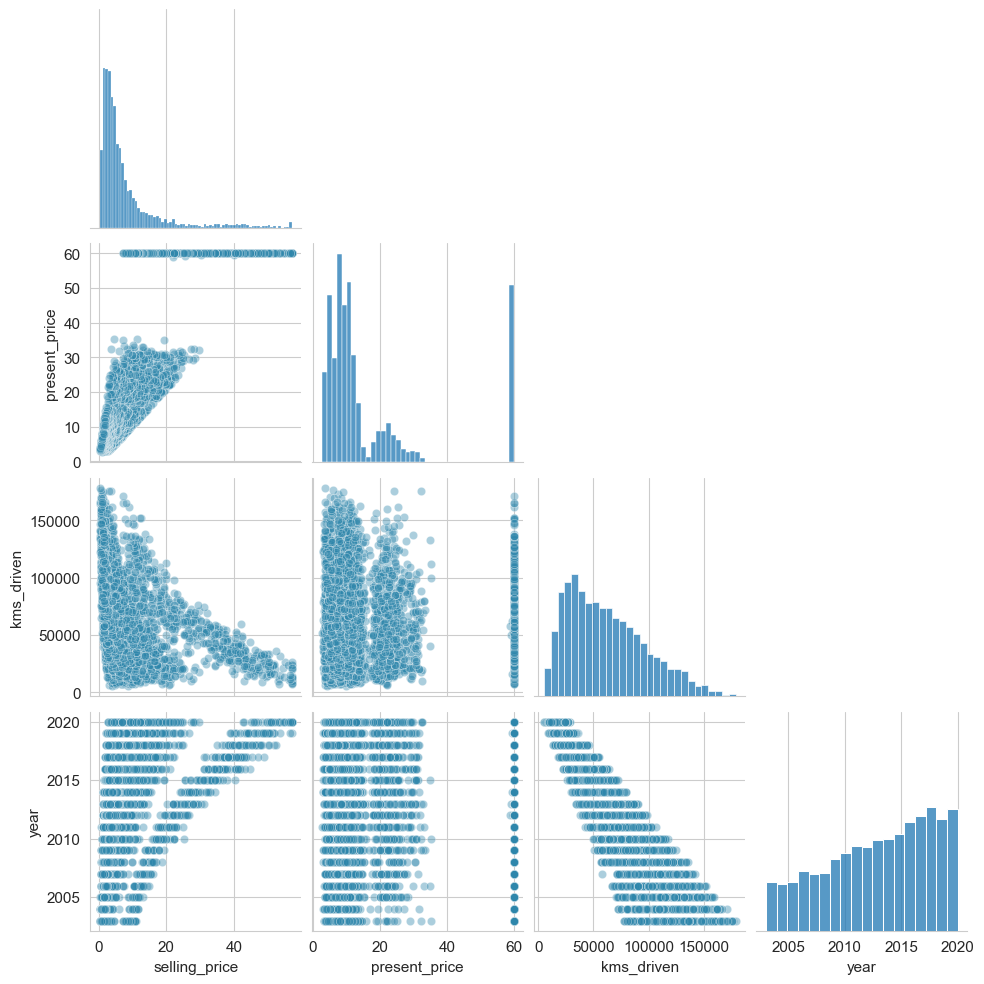

In [22]:
sns.pairplot(df[['selling_price', 'present_price', 'kms_driven', 'year']], corner=True,plot_kws={'alpha': 0.4, 'color': '#2E86AB'})
plt.savefig('plots/pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

###### 4.9 Top 10 Cars Model

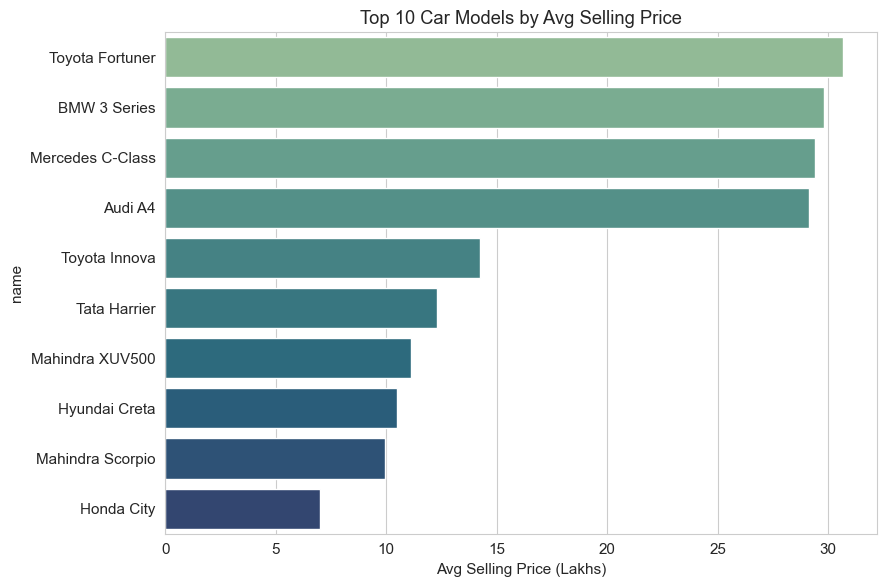

In [23]:
top_models = df.groupby('name')['selling_price'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(9, 6))
sns.barplot(x=top_models.values, y=top_models.index, palette='crest')
plt.title('Top 10 Car Models by Avg Selling Price')
plt.xlabel('Avg Selling Price (Lakhs)')
plt.tight_layout()
plt.savefig('plots/top_models_by_price.png', dpi=120, bbox_inches='tight')
plt.show()

#### 5. Feature Engineering

In [24]:
data = df.copy()
CURRENT_YEAR = 2021

# Extract brand from car name (first word)
data['brand'] = data['name'].str.split().str[0]

# Car age
data['car_age'] = CURRENT_YEAR - data['year']
data['car_age'] = data['car_age'].replace(0, 1)  # avoid divide-by-zero for brand-new cars

# Usage intensity
data['kms_per_year'] = (data['kms_driven'] / data['car_age']).round(0)

# Binary flags
data['is_automatic'] = (data['transmission'] == 'Automatic').astype(int)
data['is_first_owner'] = (data['owner'] == 0).astype(int)
data['is_dealer'] = (data['seller_type'] == 'Dealer').astype(int)

data.head()

,name,year,selling_price,present_price,kms_driven,fuel_type,seller_type,transmission,owner,brand,car_age,kms_per_year,is_automatic,is_first_owner,is_dealer
0,Tata Nexon,2020,8.67,10.31,16814,Petrol,Individual,Manual,0,Tata,1,16814.0,0,1,0
1,Mahindra XUV500,2020,20.32,23.81,15009,Petrol,Individual,Manual,0,Mahindra,1,15009.0,0,1,0
2,Maruti Alto,2020,2.92,3.18,20869,Petrol,Dealer,Manual,0,Maruti,1,20869.0,0,1,1
3,Mahindra Bolero,2020,7.54,10.29,13745,Petrol,Individual,Manual,0,Mahindra,1,13745.0,0,1,0
4,Hyundai i20,2020,7.80,8.21,10089,Diesel,Dealer,Manual,0,Hyundai,1,10089.0,0,1,1


In [25]:
# EDA-only feature (not fed to the model -- would leak target information)
df['price_depreciation_ratio'] = df['selling_price'] / df['present_price']
print(df.groupby('fuel_type')['price_depreciation_ratio'].mean().sort_values(ascending=False))

fuel_type
Diesel    0.498992
Petrol    0.486931
CNG       0.451346
Name: price_depreciation_ratio, dtype: float64


###### 5.1 Encode Categorical Variables

In [26]:
le_fuel = LabelEncoder()
le_brand = LabelEncoder()

data['fuel_type'] = le_fuel.fit_transform(data['fuel_type'])
data['brand'] = le_brand.fit_transform(data['brand'])

print("Fuel type mapping:", dict(zip(le_fuel.classes_, le_fuel.transform(le_fuel.classes_))))
print("Number of brand categories:", len(le_brand.classes_))
data.head()

Fuel type mapping: {'CNG': np.int64(0), 'Diesel': np.int64(1), 'Petrol': np.int64(2)}
Number of brand categories: 14


,name,year,selling_price,present_price,kms_driven,fuel_type,seller_type,transmission,owner,brand,car_age,kms_per_year,is_automatic,is_first_owner,is_dealer
0,Tata Nexon,2020,8.67,10.31,16814,2,Individual,Manual,0,11,1,16814.0,0,1,0
1,Mahindra XUV500,2020,20.32,23.81,15009,2,Individual,Manual,0,5,1,15009.0,0,1,0
2,Maruti Alto,2020,2.92,3.18,20869,2,Dealer,Manual,0,6,1,20869.0,0,1,1
3,Mahindra Bolero,2020,7.54,10.29,13745,2,Individual,Manual,0,5,1,13745.0,0,1,0
4,Hyundai i20,2020,7.80,8.21,10089,1,Dealer,Manual,0,4,1,10089.0,0,1,1


###### 5.2 New Features Correlation

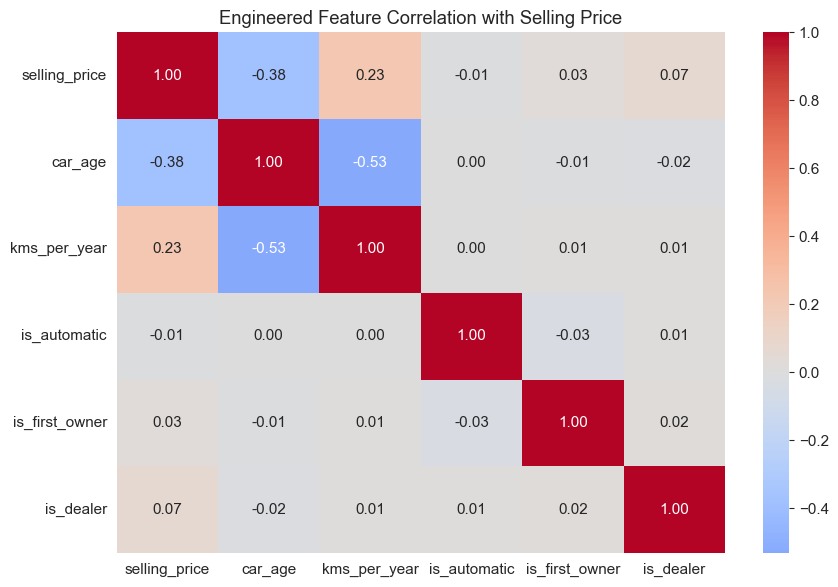

In [27]:
plt.figure(figsize=(9, 6))
engineered = ['selling_price', 'car_age', 'kms_per_year', 'is_automatic', 'is_first_owner', 'is_dealer']
sns.heatmap(data[engineered].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Engineered Feature Correlation with Selling Price')
plt.tight_layout()
plt.savefig('plots/engineered_feature_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

#### 6. Train-Test Split

In [28]:
FEATURES = ['present_price', 'kms_driven', 'fuel_type', 'transmission_encoded', 'owner','brand', 'car_age', 'kms_per_year', 'is_automatic', 'is_first_owner', 'is_dealer']

# transmission needs its own binary encoding distinct from is_automatic for the raw signal
data['transmission_encoded'] = (data['transmission'] == 'Automatic').astype(int)

TARGET = 'selling_price'

X = data[FEATURES]
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (3472, 11), Test shape: (868, 11)


In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### 7. Model Training

In [30]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=8),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=200),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, n_estimators=200, verbosity=0),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2
0,Gradient Boosting,0.560040,1.013260,0.990165
1,XGBoost,0.598477,1.155232,0.987216
2,Random Forest,0.614700,1.200154,0.986202
3,Decision Tree,0.804664,1.407146,0.981032
4,Lasso,2.505495,4.062312,0.841917
5,Linear Regression,2.544573,4.066686,0.841577
6,Ridge,2.544433,4.066708,0.841575


###### 7.1 Model Comparison Chart

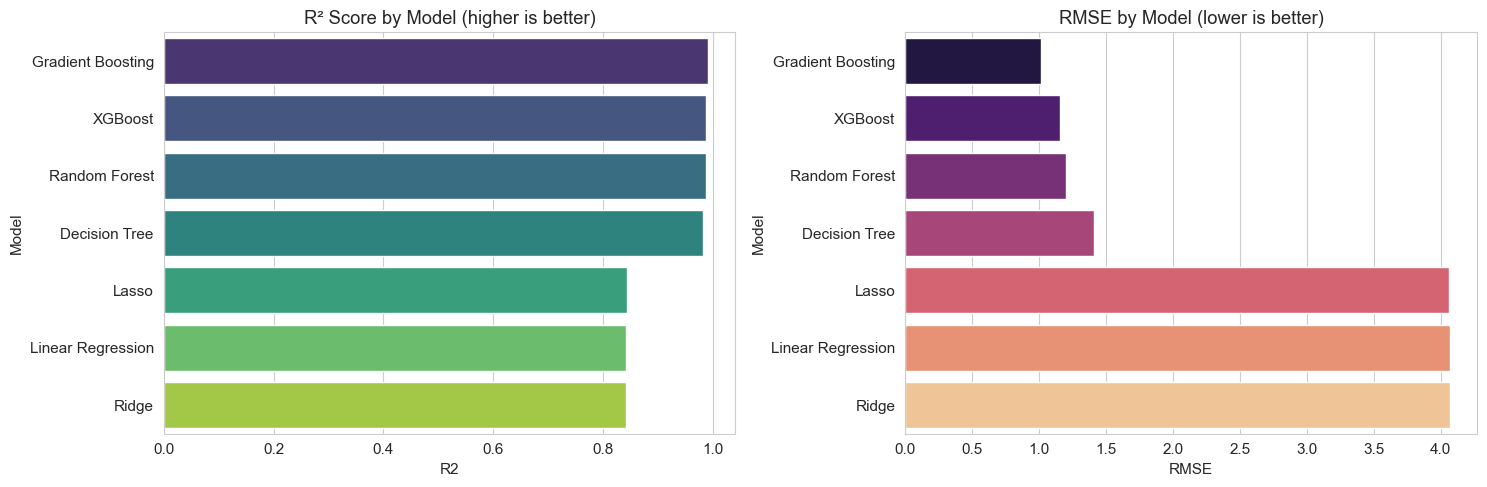

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=results_df, x='R2', y='Model', palette='viridis', ax=axes[0])
axes[0].set_title('R² Score by Model (higher is better)')

sns.barplot(data=results_df, x='RMSE', y='Model', palette='magma', ax=axes[1])
axes[1].set_title('RMSE by Model (lower is better)')

plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

#### 8. Hyperparameter Tuning

In [32]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
}

xgb = XGBRegressor(random_state=42, verbosity=0)
grid_search = GridSearchCV(
    xgb, param_grid, cv=KFold(5, shuffle=True, random_state=42),
    scoring='r2', n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best CV R²: 0.9901772930195019


In [33]:
best_model = grid_search.best_estimator_
preds = best_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"Tuned XGBoost — MAE: {mae:.2f} Lakhs | RMSE: {rmse:.2f} Lakhs | R²: {r2:.4f}")

Tuned XGBoost — MAE: 0.52 Lakhs | RMSE: 0.97 Lakhs | R²: 0.9910


#### 9. Model Evaluation

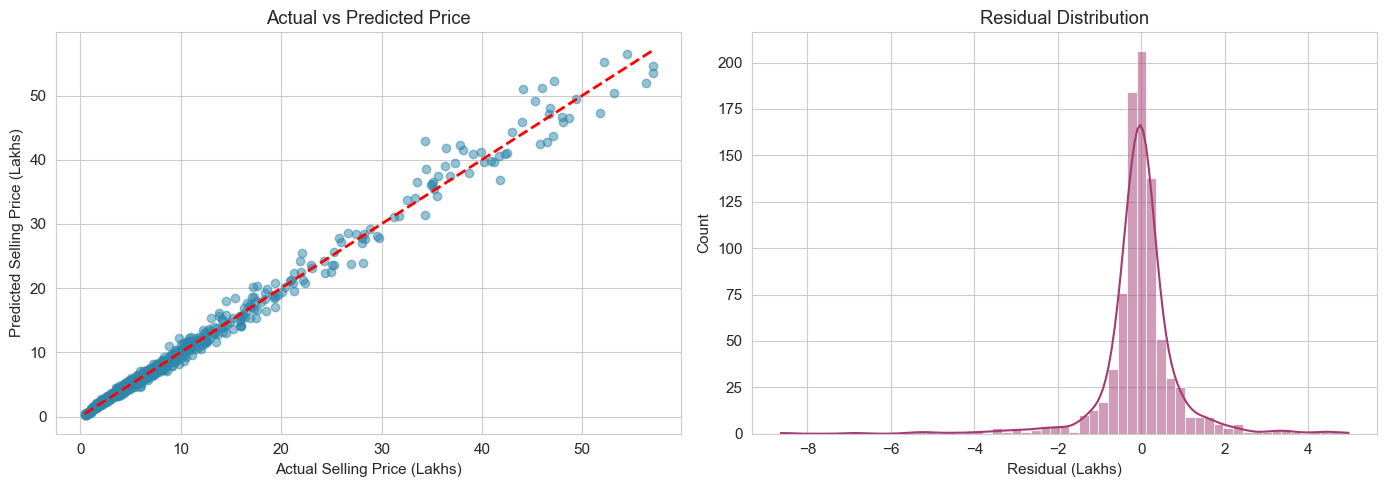

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, preds, alpha=0.5, color='#2E86AB')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Selling Price (Lakhs)')
axes[0].set_ylabel('Predicted Selling Price (Lakhs)')
axes[0].set_title('Actual vs Predicted Price')

residuals = y_test - preds
sns.histplot(residuals, kde=True, color='#A23B72', ax=axes[1])
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (Lakhs)')

plt.tight_layout()
plt.savefig('plots/model_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

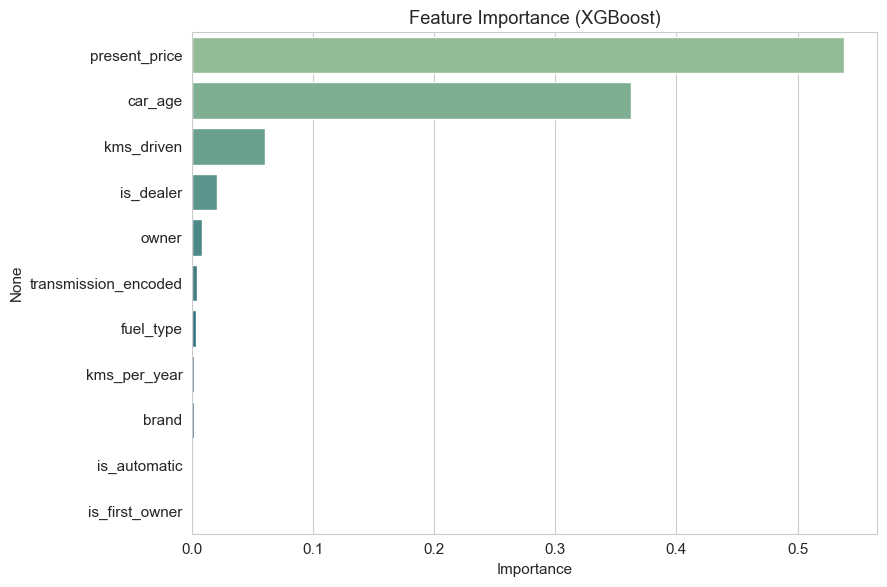

In [35]:
importance = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importance.values, y=importance.index, palette='crest')
plt.title('Feature Importance (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('plots/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

#### 10. Artifacts

In [39]:
with open('used_car_price_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('fuel_encoder.pkl', 'wb') as f:
    pickle.dump(le_fuel, f)
with open('brand_encoder.pkl', 'wb') as f:
    pickle.dump(le_brand, f)
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(FEATURES, f)

print("Artifacts saved:")
print("- used_car_price_model.pkl")
print("- scaler.pkl")
print("- fuel_encoder.pkl")
print("- brand_encoder.pkl")
print("- feature_columns.pkl")

Artifacts saved:
- used_car_price_model.pkl
- scaler.pkl
- fuel_encoder.pkl
- brand_encoder.pkl
- feature_columns.pkl
